# Introduction

## Limitation of our previous RAG

- No permanant storage of vector database
    - This will lead to suboptimal use of RAM as all the embeddings get stored in the RAM only
- Uses `Symentic Search` only
    - Symentic search means just finding nearest neighbors
    - The accuracy of the answer (result) is limited due to this reason

## Improvements in this RAG

- Permanant storage of chromadb collection
- Introduction of `Keyword Search` along with `Symentic Search`
- We will understand the use of `metadata`

### Re-ranking the context
- Re-raking models are used to rank the chunks based on their relevancy before feeding them to the LLM

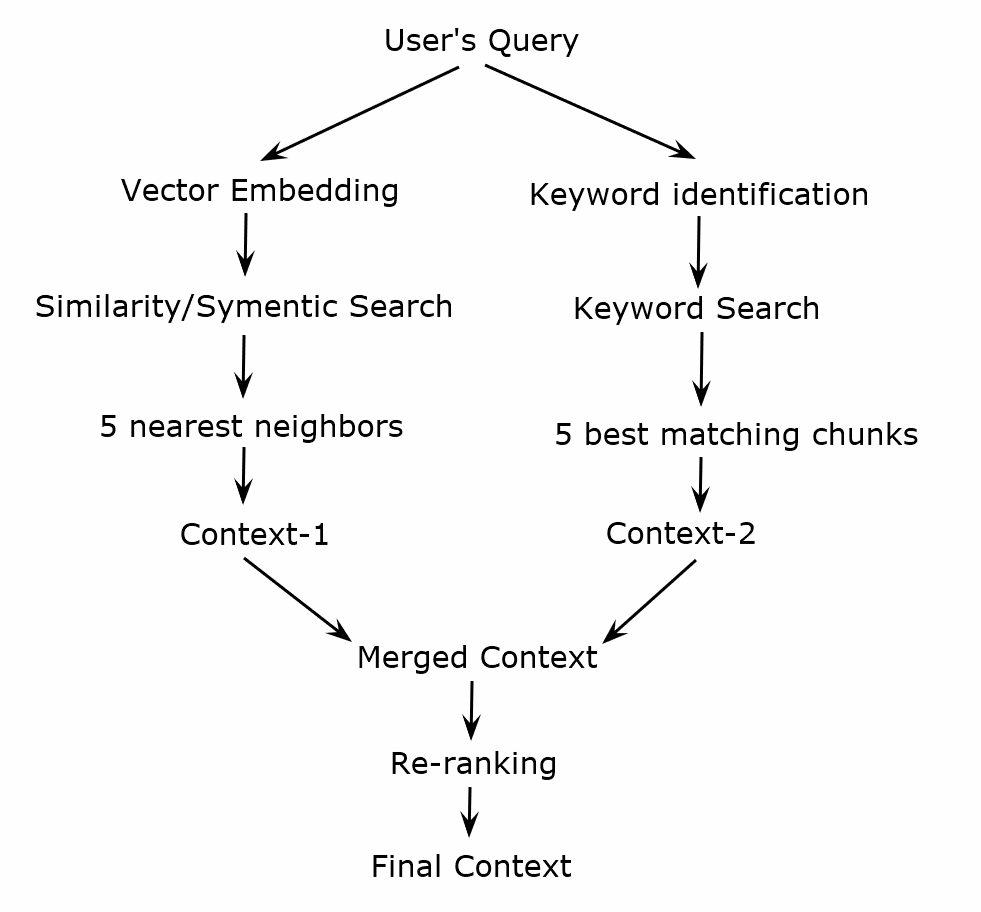

In [1]:
from openai import OpenAI
from dotenv import load_dotenv
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
import chromadb
import os
from rank_bm25 import BM25Okapi
import numpy as np

C:\Users\alakh\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

client = OpenAI(

    base_url="https://openrouter.ai/api/v1",

    api_key=os.getenv("OPENROUTER_API_KEY")
)

# ---------------- LOAD PDF ----------------
pdf_path = "gk-book.pdf"

reader = PdfReader(pdf_path)

document_text = ""

for page in reader.pages:
    document_text += page.extract_text()

print("\nPdf loaded successfully...\n")

# ----------------------- Chunking -----------------------

chunk_size = 1000

chunks = []

for i in range(0, len(document_text), chunk_size):      # i = 0, 1000, 2000, 3000....
    chunks.append(document_text[i : i+chunk_size])

print(f"\nTotal chunks created = {len(chunks)}\n")
# print(chunks)


# ----------------------- Vector Embedding Model -----------------------

embedding_model = SentenceTransformer(
    model_name_or_path= "all-MiniLM-L6-v2"
    # model_name_or_path= "multi-qa-mpnet-base-cos-v1"
)

print("\nEmbedding Model Instance created\n")


Pdf loaded successfully...


Total chunks created = 469



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1853.01it/s]



Embedding Model Instance created



In [3]:
# ----------------------- BM25 Setup -----------------------

# To perform keyword search first we need words present in the chunks

tokenized_chunks = [chunk.split() for chunk in chunks]

# print("Tokenized Chunks:\n", tokenized_chunks)
print("Tokenized Chunks:\n", np.array(tokenized_chunks[0]))

bm25 = BM25Okapi(tokenized_chunks)

Tokenized Chunks:
 ['1' '©' 'THE' 'RAMAN’S' 'BOOKS' 'SOLAR' 'SYSTEM' '-' 'STATISTICS' 'The'
 'solar' 'system' 'consists' 'of' 'the' 'Sun' 'and' '9' 'planets'
 'revolving' 'around' 'it' 'in' 'different' 'orbits.' 'The' 'statistics'
 'of' 'the' 'sun' 'and' 'the' 'planets' 'are' 'given' 'below' ':' 'SUN'
 'Age' ':' 'About' '5' 'Billion' 'years' 'Distance' ':' '149.8' 'Million'
 'Kms' 'Diameter' ':' '1,38,400' 'Kms.' 'Photosphere' 'temperature' ':'
 '5,770' 'K' 'Core' 'temperature' ':' '150,000,000' 'K' 'Absolute'
 'visual' 'magnitude' ':' '4.75' 'Rotation' '(as' 'seen' 'from' 'the'
 'earth' 'at' 'the' 'equator)' ':' '25.38' 'days' 'Rotation' '(near' 'the'
 'poles)' ':' '33' 'days' 'The' 'sun' 'consists' 'of' '71%' 'of'
 'Hydrogen,' '26.5%' 'Helium' 'and' '2.5%' 'of' 'other' 'elements.' 'The'
 'rays' 'of' 'the' 'Sun' 'take' 'about' '8' 'minutes' 'to' 'reach' 'the'
 'earth.' 'PLANETS' '(1)' 'MERCURY' ':' 'It' 'is' 'the' 'planet' 'nearest'
 'to' 'the' 'earth.' 'Average' 'distance' 'to' 'the'

In [4]:
# ----------------------- Vector Database - ChromaDB -----------------------

chromadb_client = chromadb.PersistentClient(path= "./chroma_storage")

collection = chromadb_client.get_or_create_collection(
    
    name= "enterprise_rag"

)

print("\nVector Database Created\n")


Vector Database Created



In [5]:
# ----------------------- Storing Vector Embeddings in the database -----------------------

for index, chunk in enumerate(chunks):
    embedding = embedding_model.encode(chunk).tolist()

    collection.upsert(
        ids= [str(index)],

        embeddings= [embedding],

        documents= [chunk],

        metadatas= [
            {
                "chunk_id" : index
            }
        ]
    )

print("\nEmbeddings are stored successfully.\n")


Embeddings are stored successfully.



In [6]:
# ---------------- CONVERSATION MEMORY ----------------

messages = [

    {
        "role": "system",
        "content": """
        You are an enterprise AI assistant.

        Answer questions ONLY from the provided document context.

        If answer is not available in context, just say:
        'I could not find this information in the document.'
        """
    }
]

In [10]:
# ---------------- CHAT LOOP ----------------

print("\nEnterpise RAG Started!")
print("Type 'exit' to stop.\n")

while True:

    question = input("[You] : ")

    if question.lower() == "exit":
        break

    # Store user message
    messages.append(
        {
            "role": "user",
            "content": question
        }
    )

    # ---------------- Semantic Search ----------------

    question_embedding = embedding_model.encode(question).tolist()

    semantic_results = collection.query(

        query_embeddings=[question_embedding],

        n_results=5
    )

    # print(semantic_results)
    semantic_chunks = semantic_results["documents"][0]
    # print(semantic_chunks, "\n\n")

    # ---------------- BM25 (Keyword) Search ----------------

    tokenized_query = question.split()

    bm25_result = bm25.get_top_n(
        query= tokenized_query,

        documents= chunks,

        n= 6
    )

    # print(np.array(bm25_result))

    # ---------------- Hybrid Search ----------------

    combined_chunks = list(
     
        set(semantic_chunks + bm25_result)
    
    )

    print("Final no. of chunks =", len(combined_chunks))


    # ---------------- Reranking of the chunks will come here ----------------


    # ---------------- Final Context ----------------

    final_context = "\n".join(combined_chunks)

    # print("\n:Retrieved Context:\n\n", final_context)

    # ---------------- RAG Prompt ----------------

    rag_prompt = f"""

    DOCUMENT CONTEXT:
    {final_context}

    USER QUESTION:
    {question}

    """

    # Add retrieved context
    messages.append(
        {
            "role": "system",
            "content": rag_prompt
        }
    )

    # ---------------- LLM CALL ----------------

    response = client.chat.completions.create(

        model="deepseek/deepseek-chat",

        messages=messages

        # max_tokens=200,

        # temperature=0.7
    )

    ai_reply = response.choices[0].message.content

    print("\n[AI] :", ai_reply, "\n")

    # Store assistant response
    messages.append(
        {
            "role": "assistant",
            "content": ai_reply
        }
    )


Enterpise RAG Started!
Type 'exit' to stop.

Final no. of chunks = 11

[AI] : I could not find this information in the document. 

Final no. of chunks = 11

[AI] : The document covers various title topics, including:  

1. Geographical phenomena (e.g., why days and nights are equal at the Equator, why mountains are cooler than plains).  
2. Scientific explanations (e.g., the difference between stars and planets, why wind occurs).  
3. Book listings (e.g., *Das Kapital* by Karl Marx, *David Copperfield* by Charles Dickens, *The Discovery of India* by Jawaharlal Nehru).  
4. Historical and biographical entries (e.g., Mahatma Gandhi’s life, Sher Shah’s reforms).  
5. Literary works (e.g., *Mein Kampf* by Hitler, *My Experiments with Truth* by Gandhi, *Arabian Nights* by Burton).  

However, the document does not provide a structured list of topics or chapters, so this summary is extracted from scattered references.  

Would you like details on a specific section? 

Final no. of chunks = 

APIStatusError: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 16000 tokens, but can only afford 14772. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 429, 'message': 'Provider returned error', 'provider_name': 'StreamLake', 'raw': 'deepseek/deepseek-chat is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulate your rate limits: https://openrouter.ai/settings/integrations'}, {'code': 429, 'message': 'Provider returned error', 'provider_name': 'DeepInfra', 'raw': 'deepseek/deepseek-chat is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulate your rate 